#### Multiple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/raw/economic_index.csv')

In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [10]:
df.drop(columns=['year','month'], axis=1, inplace=True)

In [11]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


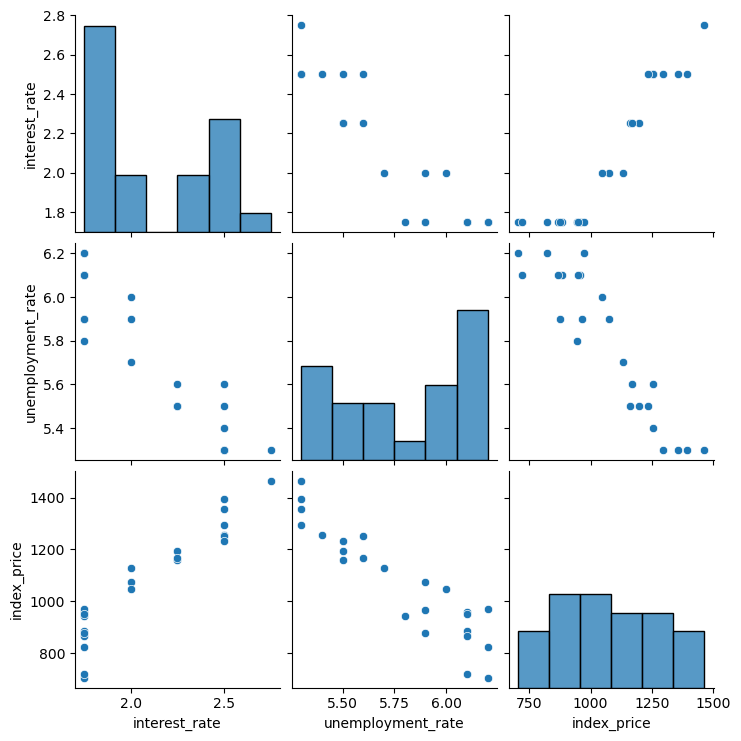

In [12]:
### Visualization
sns.pairplot(df)

In [ ]:
## Correalation
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


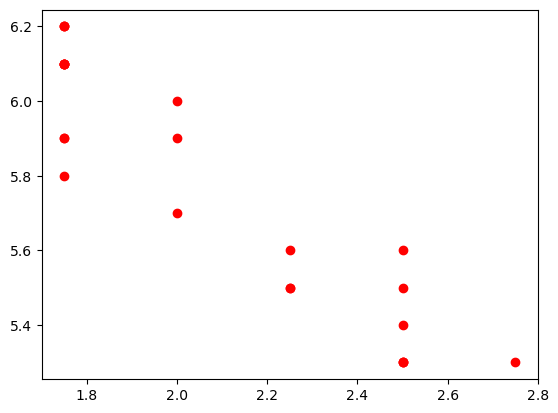

In [ ]:
#Visualizing More  Closely
plt.scatter(df['interest_rate'], df['unemployment_rate'],color='r')

#### Step 2: Get Independent & Dependent Feature

In [21]:
X=df[['interest_rate','unemployment_rate']]
y=df['index_price']

In [23]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

#### Step-3 : Train And Split

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

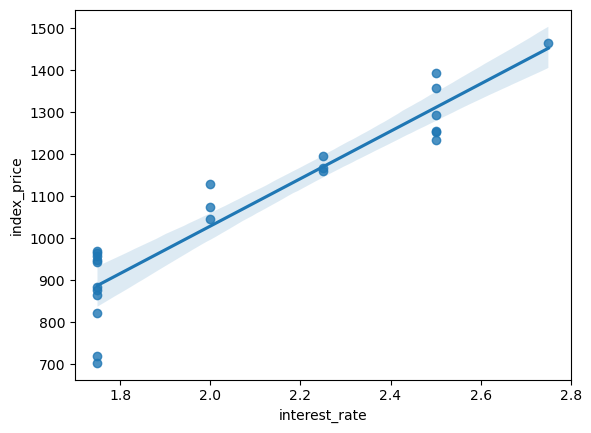

In [33]:
sns.regplot(data=df, x='interest_rate', y='index_price')

#### Step-4 Standardization

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
std = StandardScaler()

In [41]:
X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)

#### Step-5 Apply Linear Regression on the Model for Learning

In [42]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()


In [43]:
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Cross validation score
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(reg,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [46]:
np.mean(validation_score)

np.float64(-5914.82818016239)

#### Step 6 - Prediction

In [49]:
y_pred = reg.predict(X_test)

In [50]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

#### Step 7 - Performance Metrics

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [54]:
mae =mean_absolute_error(y_test,y_pred)
mse= mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)

In [55]:
print(mae)
print(mse)
print(rmse)

59.935781523235526
5793.762887712579
76.11677139574812


In [56]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.8278978091457142


#### Assumptions

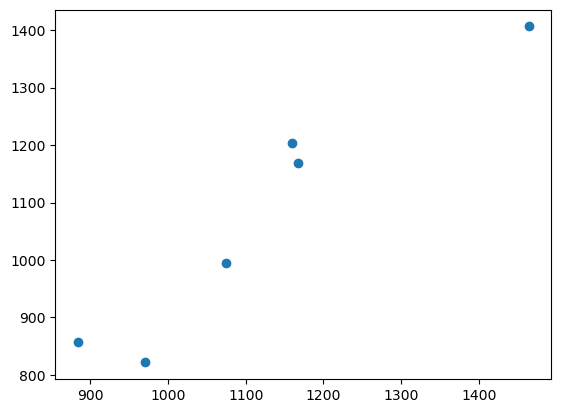

In [57]:
plt.scatter(y_test,y_pred)

In [60]:
residual =  y_test - y_pred 
print(residual)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


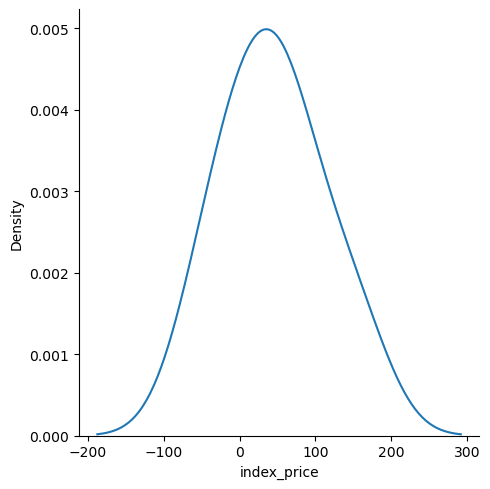

In [61]:
sns.displot(residual,kind='kde')

### The Above bell Curve graph show the model is good

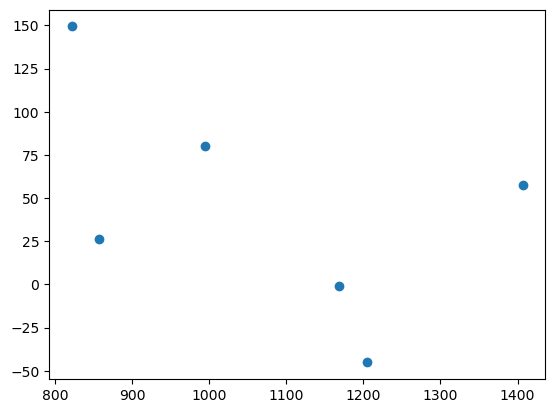

In [62]:
### Scatter
plt.scatter(y_pred,residual)

#### OLS

In [64]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
    --------------------------------------- 0.3/11.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.4 MB 764.3 kB/s eta 0:00:15
   - -------------------------------------- 0.5/11.4 MB 764.3 kB/s eta 0:00:15
   - -------------------------------------- 0.5/11.4 MB 764.3 kB/s eta 0:00:15
   -- ------------------------------------- 0.8/11.4 MB 559.5 kB/s eta 0:00:19
   -- ------------------------------------- 0.8/11.4 MB 559.5 kB/s eta 0:00:19
   --- ------------------------------------ 1.0/11.4 MB 585.6 kB/s eta 0:00:18
   --- ------------------------------------ 1.0/11.4 MB 585.6 kB/s eta 0:00:18
   --- ------------------------------------ 1.0/11.4 MB 585.6 kB/s eta 0:00:18
   --- -----------